In [425]:
# Imports & Setup
import logging
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configure logging ONCE at the top of the notebook
logging.basicConfig(
    filename="project.log",
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
)

logging.info("Notebook execution started.")

# Visualization style
sns.set_theme(style="whitegrid")
%matplotlib inline

# Ensure folder exists
os.makedirs("docs/images", exist_ok=True)

In [426]:
# Load the sales dataset
df = pd.read_csv("../data/raw/sales_data.csv")

logging.info("Loaded dataset from ../data/raw/sales_data.csv")

# Show the first few rows to confirm it loaded correctly
df.head()

,TransactionID,SaleDate,CustomerID,ProductID,StoreID,CampaignID,SaleAmount
0,1,2025-05-04,1034,2059,402,0.0,2048.2
1,2,2025-05-04,1066,2048,403,1.0,321.87
2,3,2025-05-04,1116,2041,403,3.0,3216.84
3,4,2025-05-04,1071,2096,404,2.0,1613.23
4,5,2025-05-04,1020,2060,401,0.0,408.38


In [427]:
# Inspect the structure of the DataFrame

print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isna().sum())

print("\nInfo:")
df.info()

print("\nPreview of the data:")
df.head()

logging.info(
    "Inspected DataFrame structure: shape, columns, dtypes, missing values, info, and preview."
)

Shape: (2001, 7)

Column Names:
['TransactionID', 'SaleDate', 'CustomerID', 'ProductID', 'StoreID', 'CampaignID', 'SaleAmount']

Data Types:
TransactionID      int64
SaleDate             str
CustomerID         int64
ProductID          int64
StoreID            int64
CampaignID       float64
SaleAmount           str
dtype: object

Missing Values:
TransactionID    0
SaleDate         0
CustomerID       0
ProductID        0
StoreID          0
CampaignID       1
SaleAmount       0
dtype: int64

Info:
<class 'pandas.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  2001 non-null   int64  
 1   SaleDate       2001 non-null   str    
 2   CustomerID     2001 non-null   int64  
 3   ProductID      2001 non-null   int64  
 4   StoreID        2001 non-null   int64  
 5   CampaignID     2000 non-null   float64
 6   SaleAmount     2001 non-null   str    
dtypes: f

In [428]:
# Clean and prepare the dataset

# Convert SaleAmount to numeric (turn "?" into NaN)
df["SaleAmount"] = pd.to_numeric(df["SaleAmount"], errors="coerce")

# Replace blank CampaignID with NaN
df["CampaignID"] = df["CampaignID"].replace("", pd.NA)

# Convert CampaignID to integer type
df["CampaignID"] = pd.to_numeric(df["CampaignID"], errors="coerce").astype("Int64")

# Convert SaleDate to datetime
df["SaleDate"] = pd.to_datetime(df["SaleDate"], errors="coerce")

# Show updated info
df.info()

logging.info(
    "Cleaned dataset: converted SaleAmount to numeric, fixed CampaignID blanks, standardized CampaignID type, and converted SaleDate to datetime."
)

<class 'pandas.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TransactionID  2001 non-null   int64         
 1   SaleDate       2000 non-null   datetime64[us]
 2   CustomerID     2001 non-null   int64         
 3   ProductID      2001 non-null   int64         
 4   StoreID        2001 non-null   int64         
 5   CampaignID     2000 non-null   Int64         
 6   SaleAmount     2000 non-null   float64       
dtypes: Int64(1), datetime64[us](1), float64(1), int64(4)
memory usage: 111.5 KB


In [429]:
df.describe()

,TransactionID,SaleDate,CustomerID,ProductID,StoreID,CampaignID,SaleAmount
count,2001.000000,2000,2001.000000,2001.000000,2001.000000,2000.0,2000.000000
mean,1000.002999,2025-05-04 00:00:00,1103.897051,2050.440280,402.545227,1.5035,1014.269255
min,1.000000,2025-05-04 00:00:00,1000.000000,2000.000000,401.000000,0.0,0.000000
25%,500.000000,2025-05-04 00:00:00,1046.000000,2025.000000,402.000000,0.0,251.172500
50%,1000.000000,2025-05-04 00:00:00,1099.000000,2051.000000,403.000000,2.0,731.260000
75%,1500.000000,2025-05-04 00:00:00,1150.000000,2076.000000,404.000000,2.0,1512.990000
max,2000.000000,2025-05-04 00:00:00,9999.000000,2099.000000,404.000000,3.0,6619.200000
std,577.778087,NaN,207.519764,28.586493,1.118963,1.120543,1012.721489


In [430]:
# Total Sales by Store
sales_by_store = df.groupby("StoreID")["SaleAmount"].sum().sort_values(ascending=False)

logging.info("Computed total sales by store using groupby and sorted results.")

sales_by_store

StoreID
404    553465.42
402    498619.84
403    490728.85
401    485724.40
Name: SaleAmount, dtype: float64

In [431]:
# Average Sale Amount by Product
avg_sale_by_product = (
    df.groupby("ProductID")["SaleAmount"].mean().sort_values(ascending=False)
)

logging.info(
    "Computed average sale amount by product using groupby and sorted results."
)

avg_sale_by_product

ProductID
2000    2381.733571
2086    2266.543500
2013    2151.328000
2075    2068.696364
2098    2055.064545
           ...     
2009      99.150000
2046      90.051875
2040      74.485652
2070      49.715455
2029      21.954167
Name: SaleAmount, Length: 100, dtype: float64

In [432]:
# Total Sales by Month
df["SaleMonth"] = df["SaleDate"].dt.to_period("M")

sales_by_month = df.groupby("SaleMonth")["SaleAmount"].sum()

logging.info(
    "Computed total sales by month: extracted SaleMonth period and aggregated SaleAmount."
)

sales_by_month

SaleMonth
2025-05    2027800.98
Freq: M, Name: SaleAmount, dtype: float64

In [433]:
# Correlation Matrix & Heatmap

# Compute correlation matrix
corr = df.corr(numeric_only=True)

logging.info("Computed numeric-only correlation matrix for the dataset.")

# Display the matrix
corr

,TransactionID,CustomerID,ProductID,StoreID,CampaignID,SaleAmount
TransactionID,1.000000,-0.034551,-0.019207,-0.002841,-0.026427,0.007370
CustomerID,-0.034551,1.000000,-0.010988,-0.013621,0.005565,-0.012955
ProductID,-0.019207,-0.010988,1.000000,0.002746,0.007512,0.089449
StoreID,-0.002841,-0.013621,0.002746,1.000000,0.030400,0.002817
CampaignID,-0.026427,0.005565,0.007512,0.030400,1.000000,0.048210
SaleAmount,0.007370,-0.012955,0.089449,0.002817,0.048210,1.000000


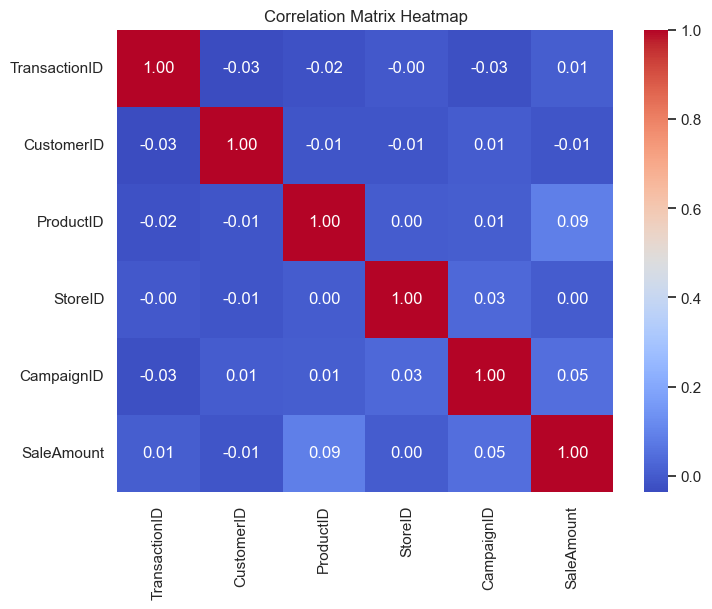

In [434]:
# Heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")


# Save the figure
plt.savefig("docs/images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

logging.info("Generated and saved correlation_heatmap.png")

plt.show()

C:\Users\JTEFE\AppData\Local\Temp\ipykernel_22040\3060250393.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_store.index, y=sales_by_store.values, palette="Blues_d")


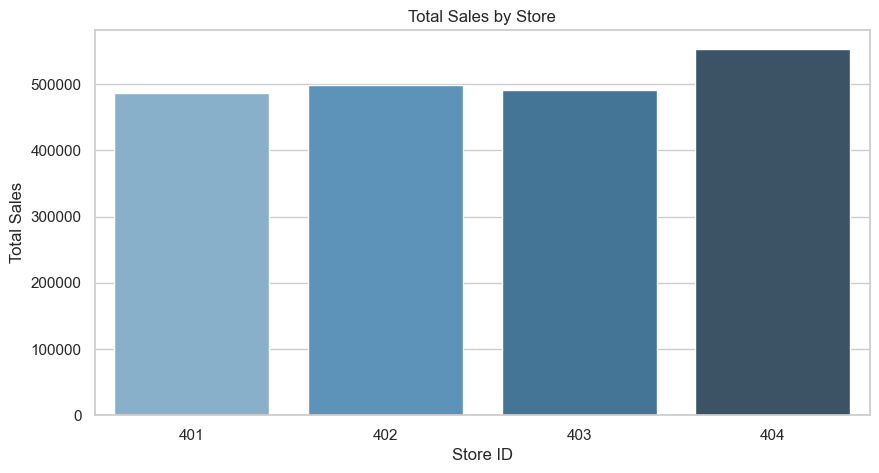

In [435]:
# Total Sales by Store (Bar Chart)
plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_store.index, y=sales_by_store.values, palette="Blues_d")
plt.title("Total Sales by Store")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")


# Save the figure
plt.savefig("docs/images/total_sales_by_store.png", dpi=300, bbox_inches="tight")

logging.info("Generated and saved total_sales_by_store.png")

plt.show()

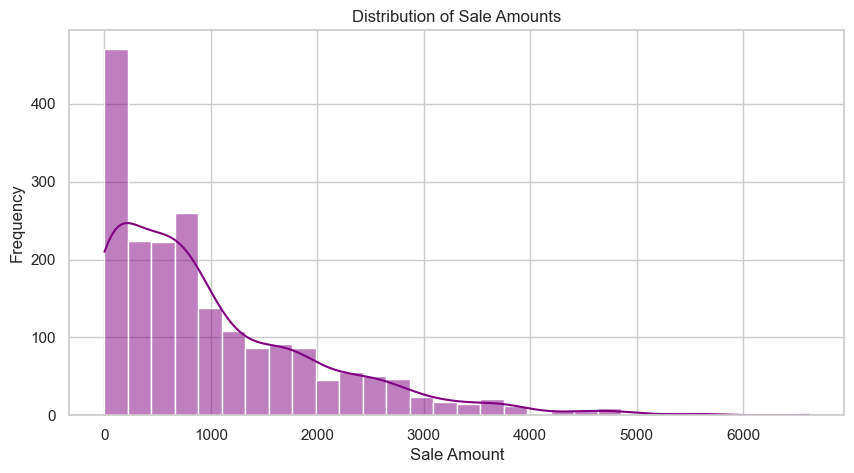

In [436]:
# Distribution of Sale Amounts
plt.figure(figsize=(10, 5))
sns.histplot(df["SaleAmount"], kde=True, bins=30, color="purple")
plt.title("Distribution of Sale Amounts")
plt.xlabel("Sale Amount")
plt.ylabel("Frequency")


# Save the figure
plt.savefig("docs/images/distribution_saleamount.png", dpi=300, bbox_inches="tight")

logging.info("Generated and saved distribution_saleamount.png")

plt.show()

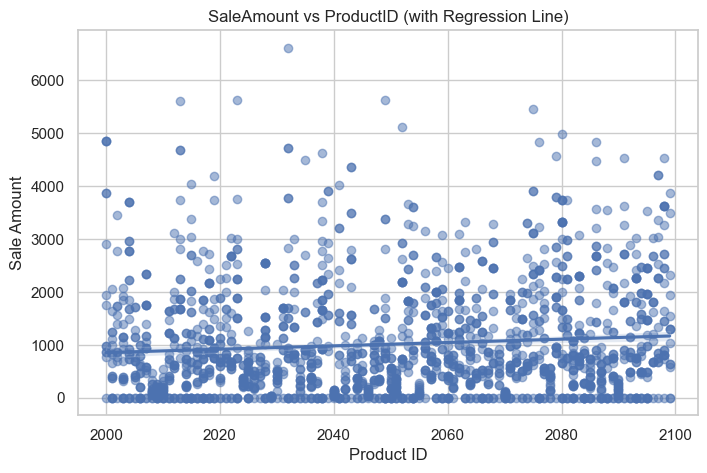

In [437]:
# Scatterplot: SaleAmount vs ProductID (Regression Line)
plt.figure(figsize=(8, 5))
sns.regplot(x="ProductID", y="SaleAmount", data=df, scatter_kws={"alpha": 0.5})
plt.title("SaleAmount vs ProductID (with Regression Line)")
plt.xlabel("Product ID")
plt.ylabel("Sale Amount")


# Save the figure with correct filename
plt.savefig("docs/images/saleamount_vs_productid.png", dpi=300, bbox_inches="tight")

logging.info("Generated and saved saleamount_vs_productid.png")

plt.show()

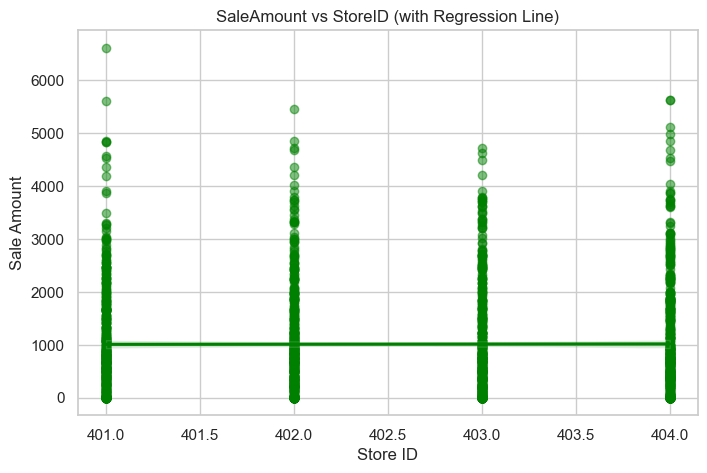

In [438]:
# Scatterplot: SaleAmount vs StoreID (Regression Line)
plt.figure(figsize=(8, 5))
sns.regplot(
    x="StoreID", y="SaleAmount", data=df, scatter_kws={"alpha": 0.5}, color="green"
)
plt.title("SaleAmount vs StoreID (with Regression Line)")
plt.xlabel("Store ID")
plt.ylabel("Sale Amount")


# Save the figure with the correct filename
plt.savefig("docs/images/saleamount_vs_storeid.png", dpi=300, bbox_inches="tight")

logging.info("Generated and saved saleamount_vs_storeid.png")

plt.show()

In [439]:
# Insights & Conclusions (Updated for 10A + 10B)

insights = [
    "1. Store-level performance shows clear differences, with some stores generating significantly higher total sales.",
    "2. Product-level averages reveal which products tend to have higher-value transactions.",
    "3. The dataset appears to cover only a single month of sales, which limits time-based trend analysis.",
    "4. The distribution of SaleAmount is right-skewed, indicating many smaller purchases and fewer high-value transactions.",
    "5. The scatterplot of SaleAmount vs ProductID (with regression line) provides insight into whether certain products tend to be associated with higher or lower sale amounts.",
    "6. The scatterplot of SaleAmount vs StoreID (with regression line) helps reveal whether specific stores tend to have higher-value transactions.",
    "7. Data cleaning successfully resolved invalid values and ensured correct data types for analysis.",
]

for line in insights:
    print(line)

logging.info("Printed final insights and conclusions for the analysis.")

1. Store-level performance shows clear differences, with some stores generating significantly higher total sales.
2. Product-level averages reveal which products tend to have higher-value transactions.
3. The dataset appears to cover only a single month of sales, which limits time-based trend analysis.
4. The distribution of SaleAmount is right-skewed, indicating many smaller purchases and fewer high-value transactions.
5. The scatterplot of SaleAmount vs ProductID (with regression line) provides insight into whether certain products tend to be associated with higher or lower sale amounts.
6. The scatterplot of SaleAmount vs StoreID (with regression line) helps reveal whether specific stores tend to have higher-value transactions.
7. Data cleaning successfully resolved invalid values and ensured correct data types for analysis.


# Final Summary

This exploratory data analysis provided a clear understanding of sales patterns, product behavior, and store performance within the dataset. Store-level analysis revealed meaningful differences in total revenue, highlighting which locations contribute most to overall sales. Product-level averages further identified which items tend to generate higher-value transactions.

Because the dataset covers only a single month of activity, long-term trend analysis was limited. However, cross-sectional insights remained strong. The distribution of SaleAmount showed a right-skewed pattern, indicating that most transactions were relatively small, with fewer high-value purchases.

Regression-based scatterplots added additional depth to the analysis. The relationship between SaleAmount and ProductID helped illustrate whether certain products tend to be associated with higher or lower sale amounts. Similarly, the scatterplot of SaleAmount vs StoreID provided insight into whether specific stores tend to generate higher-value transactions.

Data cleaning steps ensured the dataset was reliable for analysis by correcting date formats, removing invalid entries, and standardizing data types. With the data now clean and well-understood, the dataset is ready for further exploration, modeling, or business decision-making.


In [440]:
logging.info("Added final summary markdown section to the notebook.")


# Business Recommendations

Based on the insights from this exploratory data analysis, several actionable recommendations can help improve sales performance and guide future decision-making:

### 1. Focus on High-Performing Stores
Since some stores consistently generate higher total sales, consider analyzing their operational practices, staffing, product placement, or customer engagement strategies. These successful approaches can be replicated in lower-performing locations to improve overall performance.

### 2. Optimize Inventory for High-Value Products
Products with higher average sale amounts should be prioritized in inventory planning. Ensuring consistent stock levels for these items may increase revenue and reduce missed sales opportunities.

### 3. Investigate Low-Performing Products
Products associated with lower sale amounts or limited sales activity may require review. Consider adjusting pricing, bundling them with higher-value items, or improving their visibility in stores.

### 4. Leverage Store-Level Pricing or Promotions
The regression analysis between SaleAmount and StoreID suggests that certain stores may naturally drive higher-value transactions. Tailored promotions or localized pricing strategies could further amplify revenue in these high-performing locations.

### 5. Expand Data Collection for Better Trend Analysis
Because the dataset covers only one month, long-term trends cannot be assessed. Collecting additional months of data will enable deeper insights into seasonality, customer behavior, and recurring sales patterns.

### 6. Continue Strengthening Data Quality Processes
The cleaning process revealed invalid or missing values. Implementing stronger data validation at the point of entry will reduce errors and improve the reliability of future analyses.

Overall, these recommendations aim to enhance store performance, optimize product strategy, and support data-driven decision-making across the business.


In [441]:
logging.info("Added business recommendations markdown section to the notebook.")

In [442]:
logging.info("***** Notebook Executed Successfully *****")